# Dylan Navarro Badilla

## Práctica 3

Usando el dataset *obesity.csv* y guiándose con la descripción de sus variables en el archivo *obesity_description.txt*:

1. Obtenga un modelo de k-means que agrupe observaciones según atributos relacionados con **altura**, **peso** y **hábitos alimenticios** en 7 categorías de sobrepeso (*NObeysedad*).
2. Grafique los resultados de clusterización según **altura** y **peso** y obtenga el puntaje de evaluación de las estimaciones hechas por k-medias.
3. Aplique las técnicas de reducción de dimensionalidad vistas en la lección al set de datos en análisis para que este sea ahora de dos dimensiones. Genere la visualización correspondiente.
4. Ahora, entrene el modelo de agrupamiento aglomerativo con el set de datos de dos dimensiones. Grafique los resultados según altura y peso de las estimaciones y obtenga su evaluación. Compare estos resultados con los del inciso 2.

In [1]:
# importación de librerías
import pandas as pd #biblioteca para lectura de datos estructurados y su manipulación
import numpy as np  #biblioteca para realizar operaciones con vectores y matrices
import matplotlib.pyplot as plt #biblioteca para visualización de datos
from sklearn import datasets #conjuntos de datos de scikit-learn
#cargamos el conjunto de datos
obesity = pd.read_csv('/content/obesity.csv')

In [5]:
obesity.head(n=5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
obesity.shape

(2111, 17)

### 1) Obtenga un modelo de k-means que agrupe observaciones según atributos relacionados con **altura**, **peso** y **hábitos alimenticios** en 7 categorías de sobrepeso (*NObeysedad*).

### Según el archivo .txt, los atributos relacionados a los hábitos de alimentación son: FAVC, FCVC, NCP, CAEC, CH20 Y CALC. Para ello hay que concatenar los atributos:

In [31]:
from sklearn.cluster import KMeans #importamos el algoritmo

x_dum1 = pd.get_dummies(obesity[['FAVC', 'CAEC', 'CALC']])

x_num1 = obesity[['Height', 'Weight', 'FCVC', 'NCP', 'CH2O']]

# Concatenar
x = pd.concat([x_num1.reset_index(drop=True), x_dum1], axis=1).values
#pondremos a entrenar el algoritmo K Means con los 7 clústers conocidos,
#100 ejecuciones con distinta semilla para ajustar el centroide de cada clúster
#400 iteraciones maximo del algoritmo en una sola ejecución
km = KMeans(n_clusters=7, n_init=100, max_iter=400).fit(x)

#conozcamos los centroides predecidos
centers = km.cluster_centers_
print(centers)

[[ 1.64129631e+00  4.91968667e+01  2.37800467e+00  2.76300194e+00
   1.78901701e+00  2.16718266e-01  7.83281734e-01  3.40557276e-02
   4.42724458e-01  5.07739938e-01  1.54798762e-02  1.13841228e-18
   1.54798762e-02  6.22291022e-01  3.62229102e-01]
 [ 1.71789167e+00  1.03180181e+02  2.55974110e+00  2.54864814e+00
   1.91030741e+00  1.73010381e-02  9.82698962e-01  3.46020761e-03
   1.03806228e-02  9.82698962e-01  3.46020761e-03  2.16840434e-18
   3.46020761e-02  5.60553633e-01  4.04844291e-01]
 [ 1.74731422e+00  8.84729975e+01  2.25291451e+00  2.70871448e+00
   2.10230750e+00  8.06451613e-02  9.19354839e-01  3.22580645e-02
   5.64516129e-02  9.07258065e-01  4.03225806e-03  2.92734587e-18
   4.43548387e-02  5.96774194e-01  3.58870968e-01]
 [ 1.77444395e+00  1.36463388e+02  2.92642155e+00  3.00000000e+00
   2.15490496e+00  6.53594771e-03  9.93464052e-01  2.42861287e-17
   6.53594771e-03  9.93464052e-01 -3.46944695e-17  6.50521303e-19
  -6.93889390e-18  1.00000000e+00  0.00000000e+00]
 [ 1

### También se puede calcular el índice de Rand para ver qué tan bueno es el modelo:

In [13]:
from sklearn.metrics import rand_score
y_km = km.labels_
y = obesity['NObeyesdad']
print('Índice de Rand no-ajustado:', rand_score(y, y_km))
from sklearn.metrics import adjusted_rand_score
print('Índice de Rand ajustado:', adjusted_rand_score(y, y_km))

Índice de Rand no-ajustado: 0.8256148677318761
Índice de Rand ajustado: 0.30731375703681535


### 2) Grafique los resultados de clusterización según **altura** y **peso** y obtenga el puntaje de evaluación de las estimaciones hechas por k-medias.

Text(0.5, 1.0, 'Clústers Predichos (KM)')

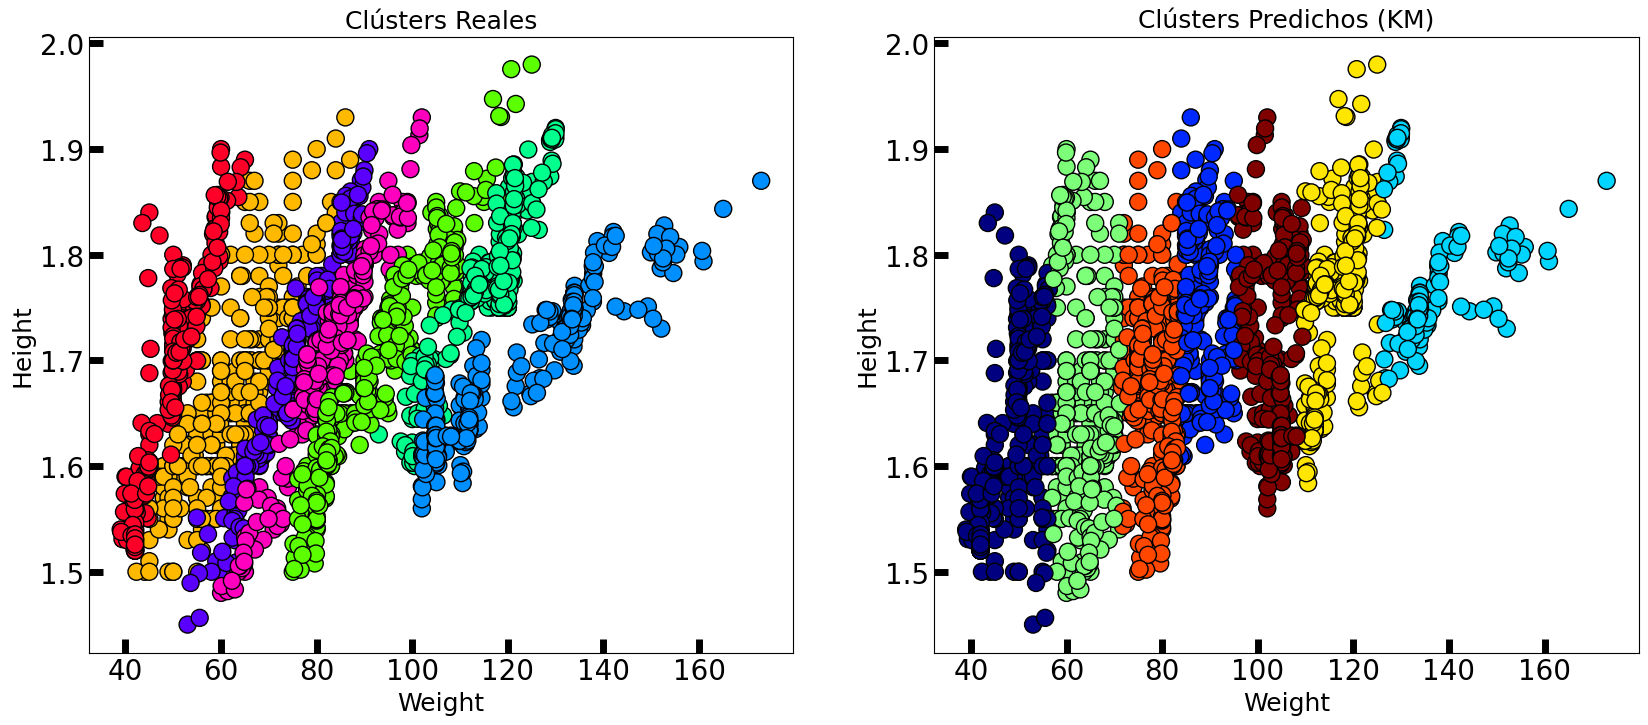

In [18]:
# Comparemos el agrupamiento de k-means con las etiquetas reales
y_num = pd.Categorical(obesity['NObeyesdad']).codes
fig, axes = plt.subplots(1, 2, figsize=(20,8))
axes[0].scatter(obesity['Weight'], obesity['Height'], c=y_num, cmap='gist_rainbow',
edgecolor='k', s=150)
axes[1].scatter(obesity['Weight'], obesity['Height'], c=y_km, cmap='jet',edgecolor='k', s=150)
axes[0].set_xlabel('Weight', fontsize=18)
axes[0].set_ylabel('Height', fontsize=18)
axes[1].set_xlabel('Weight', fontsize=18)
axes[1].set_ylabel('Height', fontsize=18)
axes[0].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[1].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[0].set_title('Clústers Reales', fontsize=18)
axes[1].set_title('Clústers Predichos (KM)', fontsize=18)

### Para el puntaje de evaluación se calcula la inercia:

In [20]:
print('Inercia de k-medias entrenado sin PCA/NMF: {}'.format(km.inertia_))

Inercia de k-medias entrenado sin PCA/NMF: 45600.09995685518


### El valor es bastante alto, lo que sugiere considerar el número de clústers.

### 3) Aplique las técnicas de reducción de dimensionalidad vistas en la lección al set de datos en análisis para que este sea ahora de dos dimensiones. Genere la visualización correspondiente.

### Se aplica el método PCA:

In [22]:
from sklearn import decomposition #importamos librería que implementa algoritmos de decomposición

#decomposición PCA
n_components = 2 #asociado a las dimensiones de interes
pca = decomposition.PCA(n_components=n_components)
pca.fit(x)
x_pca = pca.transform(x)
#verificar dimensiones
print('{}->{}'.format(x.shape, x_pca.shape))

(2111, 15)->(2111, 2)


### Se aplica el método NMF:

In [29]:
#decomposición NMF
n_components=2 #asociado a las dimensiones de interes
nmf = decomposition.NMF(n_components=n_components, max_iter=3000) #mejora de convergencia
nmf.fit(x)
x_nmf = nmf.transform(x)
print('{}->{}'.format(x.shape, x_nmf.shape))

(2111, 15)->(2111, 2)


### Se comparan los métodos:

Text(0.5, 1.0, 'NMF')

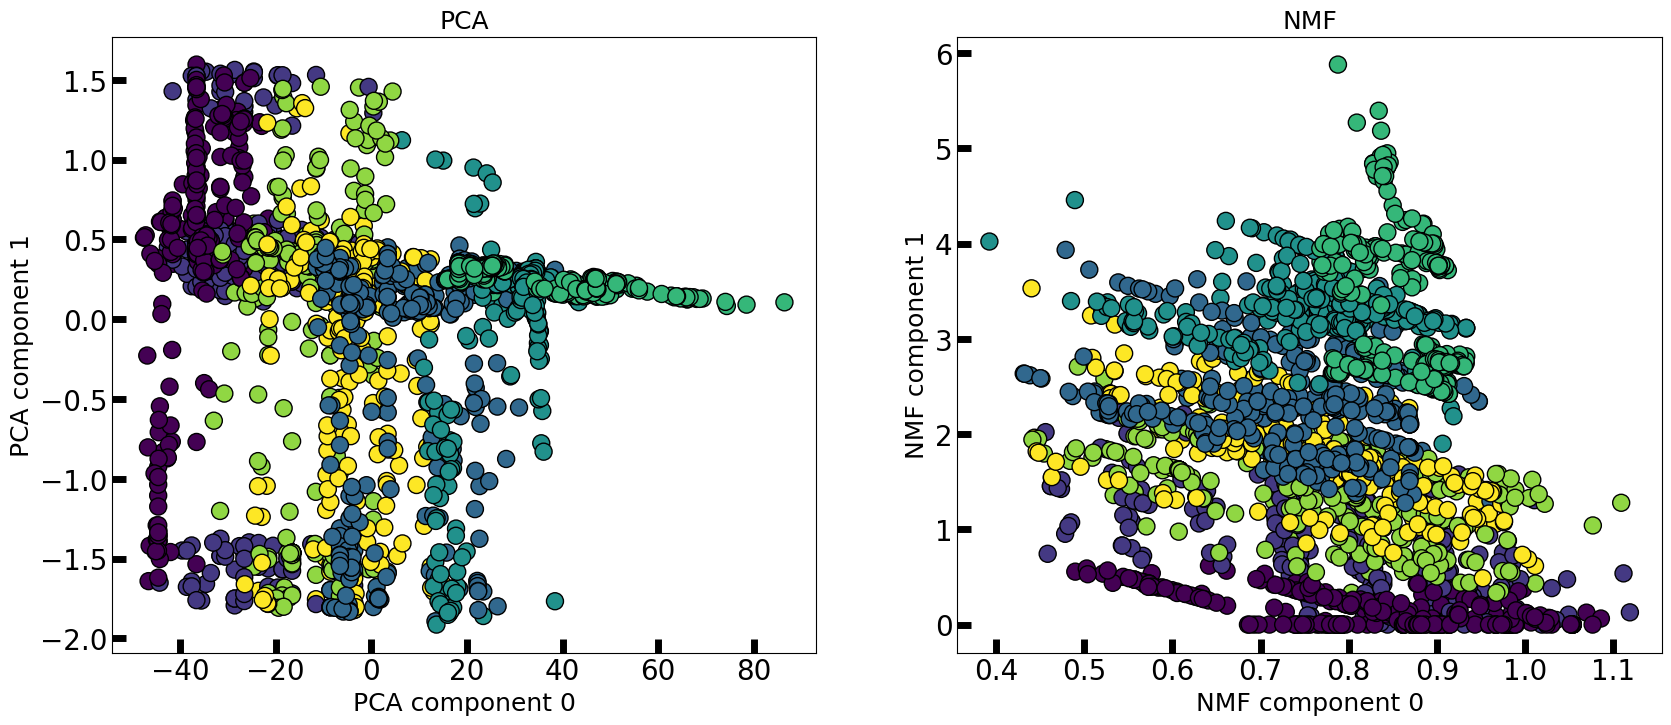

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20,8))
axes[0].scatter(x_pca[:, 0], x_pca[:, 1], c=y_num, edgecolor='k', s=150)
axes[1].scatter(x_nmf[:, 0], x_nmf[:, 1], c=y_num, edgecolor='k', s=150)
axes[0].set_xlabel('PCA component 0', fontsize=18)
axes[0].set_ylabel('PCA component 1', fontsize=18)
axes[1].set_xlabel('NMF component 0', fontsize=18)
axes[1].set_ylabel('NMF component 1', fontsize=18)
axes[0].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[1].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[0].set_title('PCA', fontsize=18)
axes[1].set_title('NMF', fontsize=18)

### 4) Ahora, entrene el modelo de agrupamiento aglomerativo con el set de datos de dos dimensiones. Grafique los resultados según altura y peso de las estimaciones y obtenga su evaluación. Compare estos resultados con los del inciso 2.

### Para PCA:

In [32]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=7,
                             metric='euclidean',
                             linkage='ward')
y_ac = ac.fit_predict(x_pca)

Text(0.5, 1.0, 'Clústers Predichos (KM)')

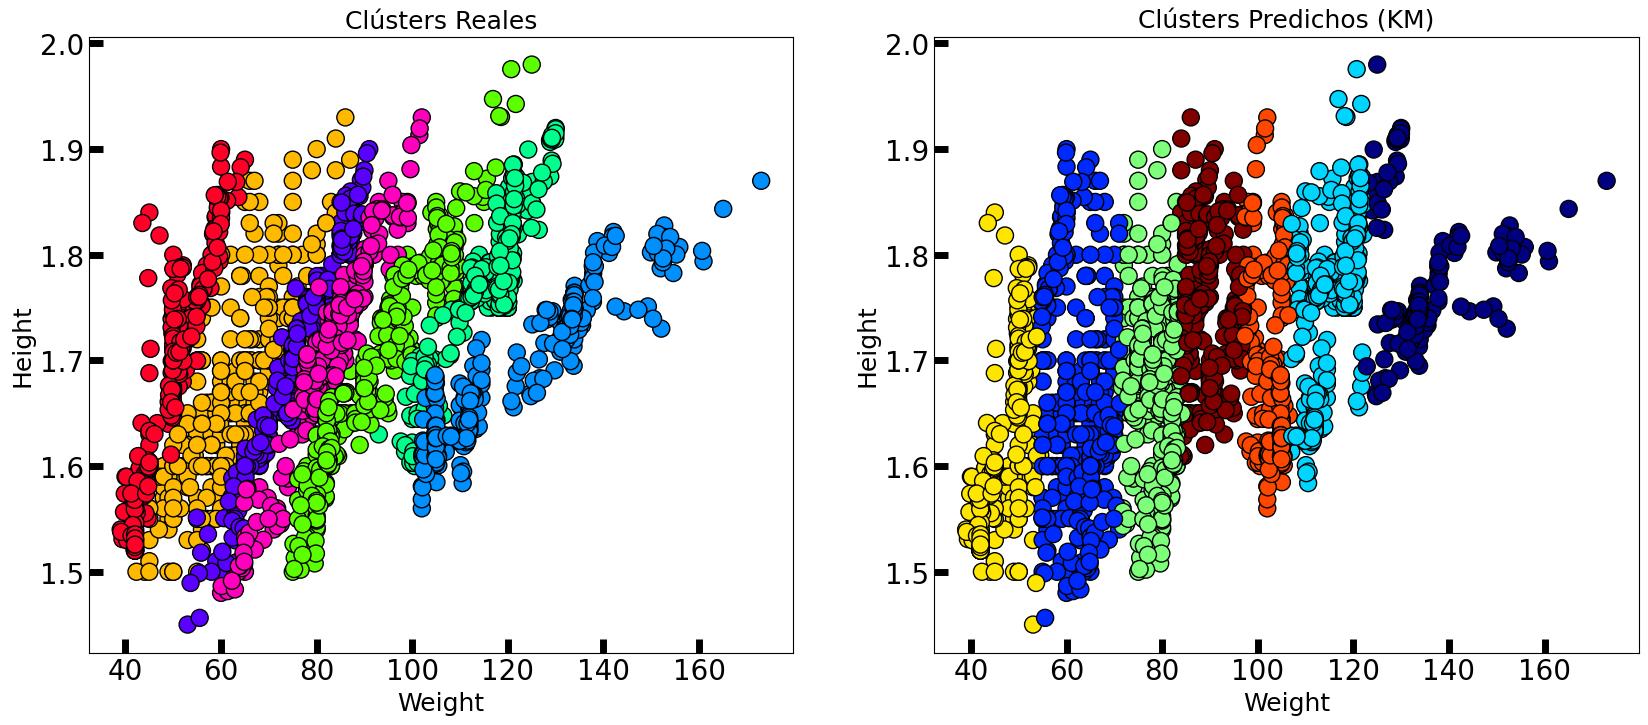

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(20,8))
axes[0].scatter(obesity['Weight'], obesity['Height'], c=y_num, cmap='gist_rainbow',
edgecolor='k', s=150)
axes[1].scatter(obesity['Weight'], obesity['Height'], c=y_ac, cmap='jet',edgecolor='k', s=150)
axes[0].set_xlabel('Weight', fontsize=18)
axes[0].set_ylabel('Height', fontsize=18)
axes[1].set_xlabel('Weight', fontsize=18)
axes[1].set_ylabel('Height', fontsize=18)
axes[0].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[1].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[0].set_title('Clústers Reales', fontsize=18)
axes[1].set_title('Clústers Predichos (KM)', fontsize=18)

### Ahora se evalúa el resultado:

In [36]:
print('Índice de Rand no-ajustado:', rand_score(y, y_km))
print('Índice de Rand ajustado:', adjusted_rand_score(y, y_km))
print('Índice de Rand no-ajustado PCA:', rand_score(y, y_ac))
print('Índice de Rand ajustado PCA:', adjusted_rand_score(y, y_ac))

Índice de Rand no-ajustado: 0.8256148677318761
Índice de Rand ajustado: 0.30731375703681535
Índice de Rand no-ajustado PCA: 0.8212163324136043
Índice de Rand ajustado PCA: 0.29428001049670893


### Para NFM:

In [39]:
from sklearn.cluster import AgglomerativeClustering
ac1 = AgglomerativeClustering(n_clusters=7,
                             metric='euclidean',
                             linkage='ward')
y_nmf = ac1.fit_predict(x_nmf)

Text(0.5, 1.0, 'Clústers Predichos (KM)')

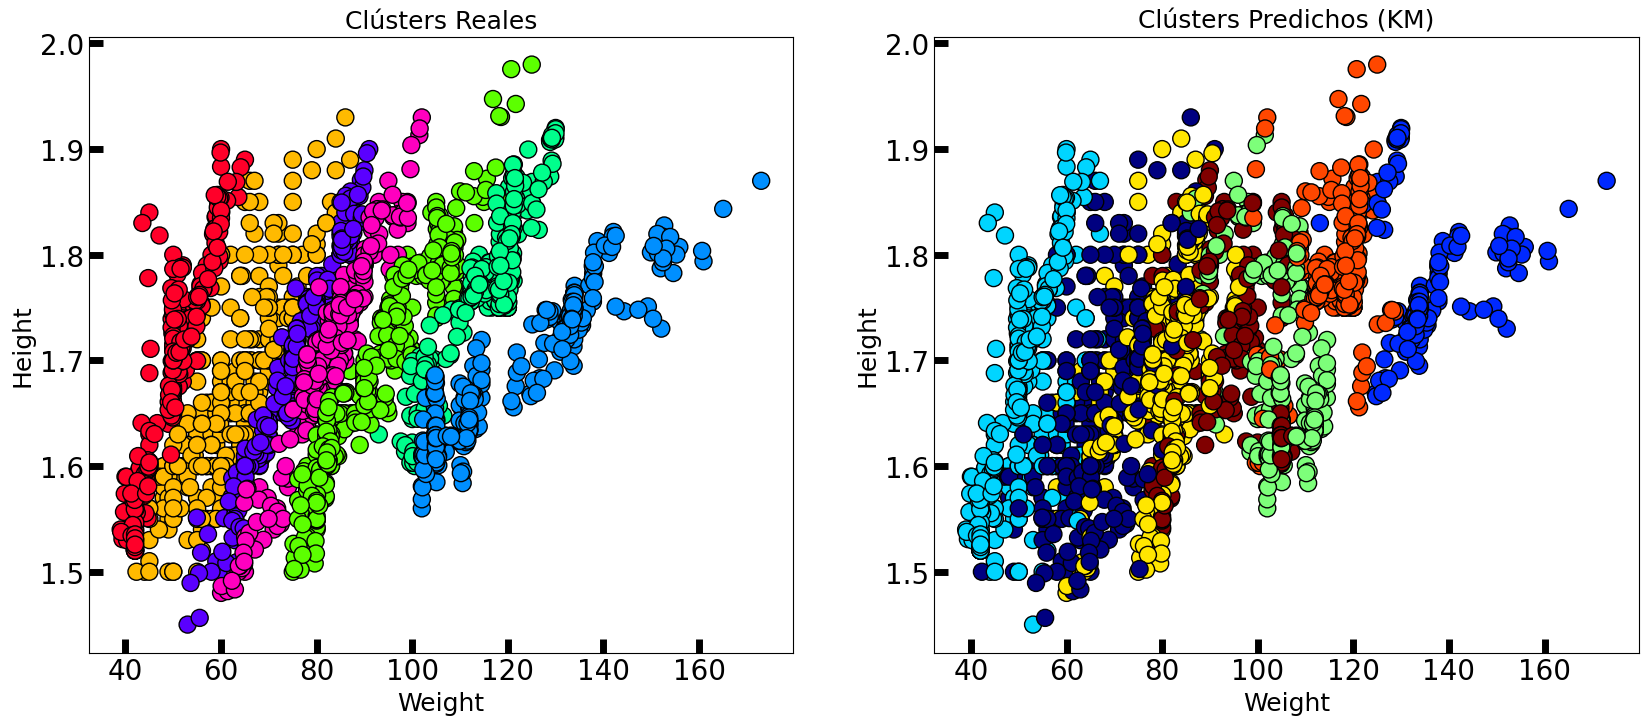

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(20,8))
axes[0].scatter(obesity['Weight'], obesity['Height'], c=y_num, cmap='gist_rainbow',
edgecolor='k', s=150)
axes[1].scatter(obesity['Weight'], obesity['Height'], c=y_nmf, cmap='jet',edgecolor='k', s=150)
axes[0].set_xlabel('Weight', fontsize=18)
axes[0].set_ylabel('Height', fontsize=18)
axes[1].set_xlabel('Weight', fontsize=18)
axes[1].set_ylabel('Height', fontsize=18)
axes[0].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[1].tick_params(direction='in', length=10, width=5, colors='k', labelsize=20)
axes[0].set_title('Clústers Reales', fontsize=18)
axes[1].set_title('Clústers Predichos (KM)', fontsize=18)

### Evaluando resultados:

In [41]:
print('Índice de Rand no-ajustado:', rand_score(y, y_km))
print('Índice de Rand ajustado:', adjusted_rand_score(y, y_km))
print('Índice de Rand no-ajustado NMF:', rand_score(y, y_nmf))
print('Índice de Rand ajustado NMF:', adjusted_rand_score(y, y_nmf))

Índice de Rand no-ajustado: 0.8256148677318761
Índice de Rand ajustado: 0.30731375703681535
Índice de Rand no-ajustado NMF: 0.8372317425536739
Índice de Rand ajustado NMF: 0.3566655901501481


Para ambos métodos los índices de Rand realmente no cambian mucho, por lo que las mejorías no son realmente notorias.